# Analyse de données automatisée

Ce notebook a été généré automatiquement en fonction des données fournies et des réponses au formulaire.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')


In [2]:

# Chargement des données
df1 = pd.read_csv('Datasets/Tabular/Test/dataset1_with_target.csv')
df2 = pd.read_csv('Datasets/Tabular/Test/dataset2_features_only.csv')

# Définir la colonne d'ID commune
common_id_column = "ID"

print("df1 shape:", df1.shape)
print("df2 shape:", df2.shape)
print(f"Colonne ID commune: {common_id_column}")


df1 shape: (1000, 11)
df2 shape: (1000, 11)
Colonne ID commune: ID


## Merge CSVs with Common ID

In [3]:
# Merge multiple CSV files on a common ID column
print(f"Merging datasets on column: {common_id_column}")

# Check if the common ID column exists in both datasets
if common_id_column in df1.columns and common_id_column in df2.columns:
    # Perform the merge
    merged_df = pd.merge(df1, df2, on=common_id_column, how='inner')
    
    print(f"Merged dataset shape: {merged_df.shape}")
    print(f"Original df1 shape: {df1.shape}, df2 shape: {df2.shape}")
    
    # Check how many rows were preserved in the merge
    print(f"Rows preserved: {merged_df.shape[0]} out of {df1.shape[0]} from df1")
    
    # Show the first few rows of the merged dataset
    merged_df.head()
else:
    print(f"Error: Common ID column '{common_id_column}' not found in both datasets")
    print(f"df1 columns: {df1.columns.tolist()}")
    print(f"df2 columns: {df2.columns.tolist()}")


Merging datasets on column: ID
Merged dataset shape: (1000, 21)
Original df1 shape: (1000, 11), df2 shape: (1000, 11)
Rows preserved: 1000 out of 1000 from df1


Distribution de la variable cible:
YTarget
0    502
1    498
Name: count, dtype: int64


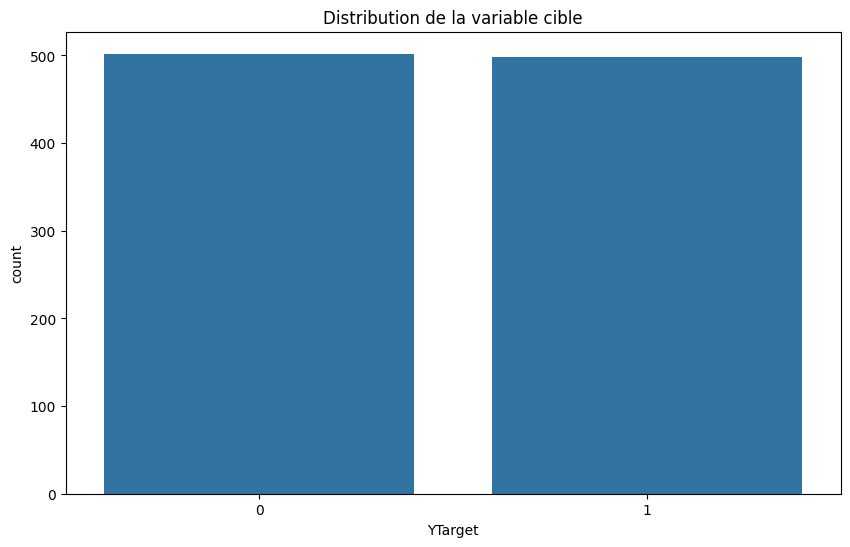

In [4]:

# Analyse de la variable cible
if 'YTarget' in merged_df.columns:
    print("Distribution de la variable cible:")
    target_counts = merged_df['YTarget'].value_counts()
    print(target_counts)
    
    plt.figure(figsize=(10, 6))
    sns.countplot(x='YTarget', data=merged_df)
    plt.title('Distribution de la variable cible')
    plt.show()


Accuracy: 0.915
Precision: 0.9019607843137255
Recall: 0.9292929292929293
F1 Score: 0.9154228855721394


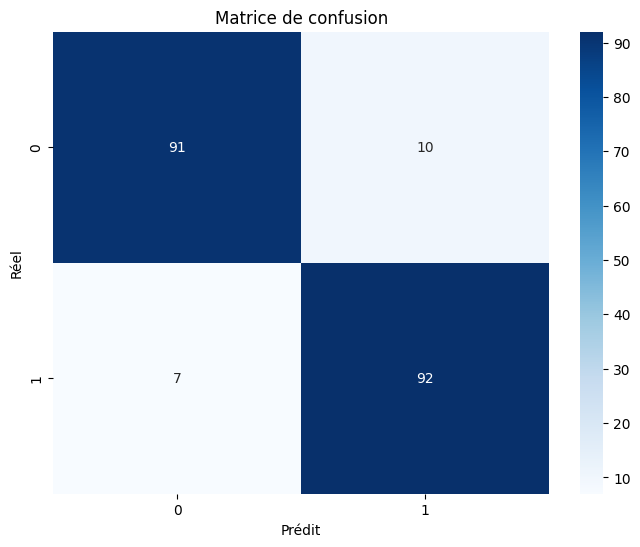

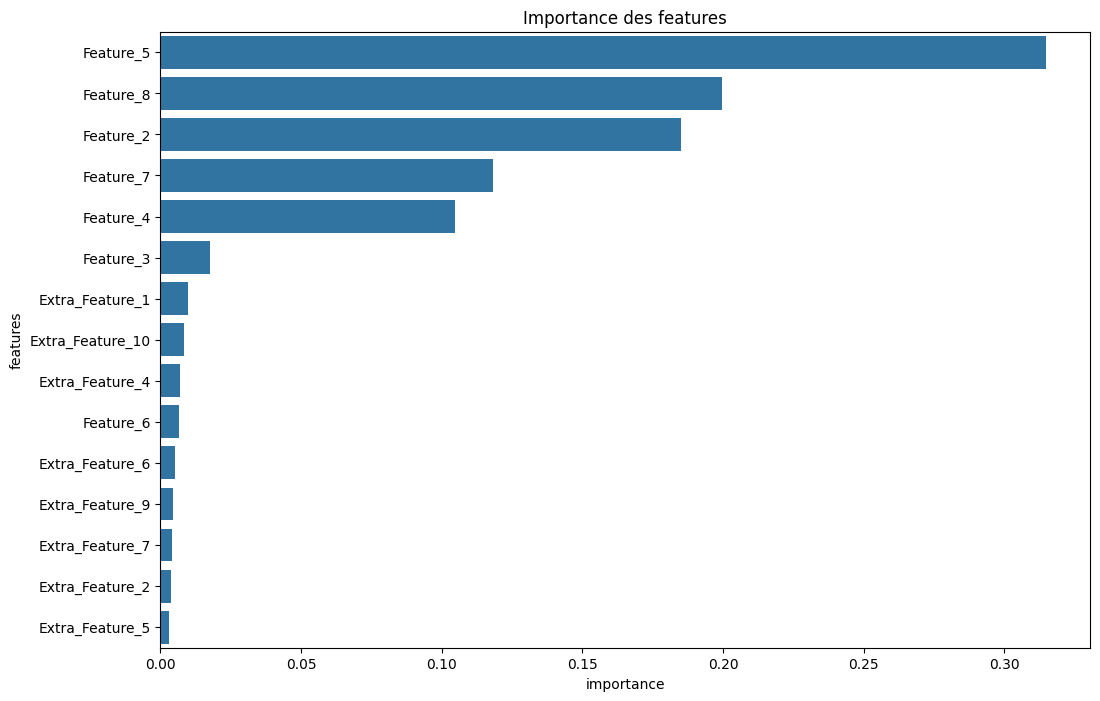

In [5]:

# Préparation des données pour la modélisation
if 'YTarget' in merged_df.columns:
    # Séparer les features et la cible
    X = merged_df.drop(['YTarget', 'ID'], axis=1)
    y = merged_df['YTarget']
    
    # Diviser en ensembles d'entraînement et de test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Entraîner un modèle GradientBoosting
    model = GradientBoostingClassifier(random_state=42)
    model.fit(X_train, y_train)
    
    # Évaluer le modèle
    y_pred = model.predict(X_test)
    
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    
    # Afficher la matrice de confusion
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Matrice de confusion')
    plt.xlabel('Prédit')
    plt.ylabel('Réel')
    plt.show()
    
    # Afficher l'importance des features
    plt.figure(figsize=(12, 8))
    feature_importance = pd.DataFrame({
        'features': X.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    sns.barplot(x='importance', y='features', data=feature_importance.head(15))
    plt.title('Importance des features')
    plt.show()


## Conclusion

Ce notebook a automatiquement analysé vos données et créé un modèle de base. Vous pouvez maintenant explorer davantage les données et améliorer le modèle selon vos besoins.